In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations


# **Question 1 Part (A)**

## **Read And Fix**

In [ ]:
df = pd.read_csv('pakwheels.csv')
df = df.drop(columns=['Unnamed: 0'])
display(df.head())

## **Data Inspection**

In [ ]:
print("First 5 rows of the DataFrame:")
display(df.head())

print("\nDataFrame Info:")
display(df.info())

print("\nMissing values per column:")
display(df.isnull().sum())

print("\nDescriptive statistics for numerical columns:")
display(df.describe())

First 5 rows of the DataFrame:


,ad_url,title,location,model_year,price,mileage,engine_type,transmission,registered_in,color,assembly,engine_capacity,body_type,ad_last_updated,car_features,description
0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC 2007,Islamabad Islamabad,2007.0,PKR 16.5 lacs,"100,000 km",Petrol,Automatic,Lahore,Grey,Imported Cars,1800 cc,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,2007 model full option Chat piller geniune or ...
1,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2012,"Eden Gardens, Faisalabad Punjab",2012.0,PKR 7 lacs,"100,000 km",Petrol,Manual,Faisalabad,Grey,Imported Cars,800 cc,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,"Very smooth drive,70% in orignal paint rest of..."
2,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic EX 1995,"Bostan Road, Rawalpindi Punjab",1995.0,PKR 7.6 lacs,999 km,Petrol,Manual,Lahore,Black,Imported Cars,1500 cc,Sedan,"Oct 09, 2022",AM/FM Radio\nAir Conditioning\nAlloy Rims\nCas...,1600cc Engine installed Alloy RimsAir Conditio...
3,https://www.pakwheels.com/used-cars/toyota-for...,Toyota Fortuner 2.7 VVTi 2013,"Kallar Kahar Road, Chakwal Punjab",2013.0,PKR 70 lacs,"94,000 km",Petrol,Automatic,Lahore,Black,Imported Cars,2700 cc,SUV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Original return fil...
4,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2015,Muzaffar Gargh Punjab,2015.0,PKR 8 lacs,"86,000 km",Petrol,Manual,Multan,Grey,Imported Cars,796 cc,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,gari total genion hy.chill a.c.new tires.no wo...



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89956 entries, 0 to 89955
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ad_url           89956 non-null  object 
 1   title            89956 non-null  object 
 2   location         89954 non-null  object 
 3   model_year       87449 non-null  float64
 4   price            89954 non-null  object 
 5   mileage          89954 non-null  object 
 6   engine_type      89001 non-null  object 
 7   transmission     89954 non-null  object 
 8   registered_in    89954 non-null  object 
 9   color            88093 non-null  object 
 10  assembly         89956 non-null  object 
 11  engine_capacity  89954 non-null  object 
 12  body_type        81407 non-null  object 
 13  ad_last_updated  89954 non-null  object 
 14  car_features     83435 non-null  object 
 15  description      89954 non-null  object 
dtypes: float64(1), object(15)
memory usage: 1

None


Missing values per column:


ad_url                0
title                 0
location              2
model_year         2507
price                 2
mileage               2
engine_type         955
transmission          2
registered_in         2
color              1863
assembly              0
engine_capacity       2
body_type          8549
ad_last_updated       2
car_features       6521
description           2
dtype: int64


Descriptive statistics for numerical columns:


,model_year
count,87449.000000
mean,2012.861576
std,7.669485
min,1990.000000
25%,2007.000000
50%,2015.000000
75%,2019.000000
max,2022.000000


## **Fix Prices**

In [ ]:
import re
def clean_price(value):
    if pd.isna(value):
        return None
    s = str(value).lower().strip()
    s = re.sub(r'rs\.?|rupees|,|\(|\)|approx|~', '', s)  
    s = s.strip()  
    total = 0.0
    crore_matches = re.findall(r'([\d\.]+)\s*crore', s)
    lakh_matches = re.findall(r'([\d\.]+)\s*(lakh|lac)', s)
    plain_number = re.findall(r'^[\d\.]+$', s)
    for c in crore_matches:
        total += float(c) * 10000000 
    for l in lakh_matches:
        total += float(l[0]) * 100000  
    if total == 0 and plain_number:
        try:
            total = float(plain_number[0])
        except:
            total = None
    if total == 0:
        s = re.sub(r'[^0-9\.]', '', s)
        try:
            total = float(s)
        except:
            total = None
    return total
df['price'] = df['price'].apply(clean_price)
display(df[['price']].head())
display(df['price'].describe())

,price
0,1650000.0
1,700000.0
2,760000.0
3,7000000.0
4,800000.0


count    8.854900e+04
mean     3.045594e+06
std      4.049545e+06
min      8.200000e+04
25%      1.180000e+06
50%      2.150000e+06
75%      3.590000e+06
max      1.150000e+08
Name: price, dtype: float64

## **Fix Milaege**

In [ ]:
def clean_mileage(mileage_str):
    if pd.isna(mileage_str):
        return np.nan
    mileage_str = mileage_str.replace('km', '').replace(',', '').strip()
    try:
        return float(mileage_str)
    except ValueError:
        return np.nan

df['mileage'] = df['mileage'].apply(clean_mileage)
print("Mileage column converted to numerical (km):")
display(df[['mileage']].head())
display(df['mileage'].describe())

Mileage column converted to numerical (km):


,mileage
0,100000.0
1,100000.0
2,999.0
3,94000.0
4,86000.0


count      89954.000000
mean       84271.617182
std        90457.662067
min            1.000000
25%        20000.000000
50%        74000.000000
75%       120000.000000
max      1000000.000000
Name: mileage, dtype: float64

## **Fix Engine Capacity**

In [ ]:
def clean_engine_capacity(capacity_str):
    if pd.isna(capacity_str):
        return np.nan
    capacity_str = capacity_str.replace('cc', '').replace(',', '').strip()
    try:
        return float(capacity_str)
    except ValueError:
        return np.nan

df['engine_capacity'] = df['engine_capacity'].apply(clean_engine_capacity)
print("Engine Capacity column converted to numerical (cc):")
display(df[['engine_capacity']].head())
display(df['engine_capacity'].describe())

Engine Capacity column converted to numerical (cc):


,engine_capacity
0,1800.0
1,800.0
2,1500.0
3,2700.0
4,796.0


count    89820.000000
mean      1406.176152
std        737.008529
min        100.000000
25%       1000.000000
50%       1300.000000
75%       1600.000000
max      15000.000000
Name: engine_capacity, dtype: float64

## **After Fixing**

In [ ]:
display(df)

,ad_url,title,location,model_year,price,mileage,engine_type,transmission,registered_in,color,assembly,engine_capacity,body_type,ad_last_updated,car_features,description
0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC 2007,Islamabad Islamabad,2007.0,1650000.0,100000.0,Petrol,Automatic,Lahore,Grey,Imported Cars,1800.0,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,2007 model full option Chat piller geniune or ...
1,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2012,"Eden Gardens, Faisalabad Punjab",2012.0,700000.0,100000.0,Petrol,Manual,Faisalabad,Grey,Imported Cars,800.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,"Very smooth drive,70% in orignal paint rest of..."
2,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic EX 1995,"Bostan Road, Rawalpindi Punjab",1995.0,760000.0,999.0,Petrol,Manual,Lahore,Black,Imported Cars,1500.0,Sedan,"Oct 09, 2022",AM/FM Radio\nAir Conditioning\nAlloy Rims\nCas...,1600cc Engine installed Alloy RimsAir Conditio...
3,https://www.pakwheels.com/used-cars/toyota-for...,Toyota Fortuner 2.7 VVTi 2013,"Kallar Kahar Road, Chakwal Punjab",2013.0,7000000.0,94000.0,Petrol,Automatic,Lahore,Black,Imported Cars,2700.0,SUV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Original return fil...
4,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2015,Muzaffar Gargh Punjab,2015.0,800000.0,86000.0,Petrol,Manual,Multan,Grey,Imported Cars,796.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,gari total genion hy.chill a.c.new tires.no wo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89951,https://www.pakwheels.com/used-cars/daihatsu-m...,Daihatsu Mira G SA III 2018,"Gulshan-e-Iqbal, Karachi Sindh",2018.0,3000000.0,65000.0,Petrol,Automatic,Sindh,White,Imported,660.0,Hatchback,"Aug 26, 2022",ABS\nAir Bags\nAir Conditioning\nAlloy Rims\nI...,100% original. Alloy Rims. Authorized dealersh...
89952,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic Oriel 1.8 i-VTEC CVT 2017,"Tandlianwala Town, Faisalabad Punjab",2017.0,3750000.0,114000.0,Petrol,Automatic,Islamabad,Silver,Imported Cars,1800.0,Sedan,"Aug 31, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,only call\nMention PakWheels.com when calling ...
89953,https://www.pakwheels.com/used-cars/toyota-cor...,Toyota Corolla GLi Automatic 1.6 VVTi 2011,Lahore Punjab,2011.0,2235000.0,152000.0,Petrol,Automatic,Lahore,Silver,Imported Cars,1600.0,Sedan,"Aug 31, 2022",ABS\nAM/FM Radio\nAir Conditioning\nCD Player\...,After Market Alloy rims. All original document...
89954,https://www.pakwheels.com/used-cars/suzuki-swi...,Suzuki Swift DLX 1.3 2013,"Gulshan-e-Iqbal, Karachi Sindh",2013.0,1550000.0,104000.0,Petrol,Manual,Karachi,Silver,Imported Cars,1300.0,Hatchback,"Aug 31, 2022",ABS\nAM/FM Radio\nAir Conditioning\nAlloy Rims...,sides shower chat diggi bonet original car on ...


## **Checkig And Handling Missing**

In [ ]:
display(df.isna().sum())

ad_url                0
title                 0
location              2
model_year         2507
price              1407
mileage               2
engine_type         955
transmission          2
registered_in         2
color              1863
assembly              0
engine_capacity     136
body_type          8549
ad_last_updated       2
car_features       6521
description           2
dtype: int64

In [ ]:
cols_to_check = ['location', 'mileage', 'transmission', 
                 'registered_in', 'engine_capacity', 
                 'ad_last_updated', 'description']

df = df.dropna(subset=cols_to_check)
print("\nAfter Cleaning:")
display(df.isna().sum())



After Cleaning:


ad_url                0
title                 0
location              0
model_year         2505
price              1371
mileage               0
engine_type         819
transmission          0
registered_in         0
color              1852
assembly              0
engine_capacity       0
body_type          8520
ad_last_updated       0
car_features       6507
description           0
dtype: int64

### **Checking Assembly and Fixing**

In [ ]:
df.loc[:, 'assembly'] = df['assembly'].replace({'Imported Cars': 'Imported'})

In [ ]:
num_unique = df['assembly'].nunique()
display(num_unique)
unique_values = df['assembly'].unique()
display(unique_values)
display(df.head())



1

array(['Imported'], dtype=object)

,ad_url,title,location,model_year,price,mileage,engine_type,transmission,registered_in,color,assembly,engine_capacity,body_type,ad_last_updated,car_features,description
0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC 2007,Islamabad Islamabad,2007.0,1650000.0,100000.0,Petrol,Automatic,Lahore,Grey,Imported,1800.0,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,2007 model full option Chat piller geniune or ...
1,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2012,"Eden Gardens, Faisalabad Punjab",2012.0,700000.0,100000.0,Petrol,Manual,Faisalabad,Grey,Imported,800.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,"Very smooth drive,70% in orignal paint rest of..."
2,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic EX 1995,"Bostan Road, Rawalpindi Punjab",1995.0,760000.0,999.0,Petrol,Manual,Lahore,Black,Imported,1500.0,Sedan,"Oct 09, 2022",AM/FM Radio\nAir Conditioning\nAlloy Rims\nCas...,1600cc Engine installed Alloy RimsAir Conditio...
3,https://www.pakwheels.com/used-cars/toyota-for...,Toyota Fortuner 2.7 VVTi 2013,"Kallar Kahar Road, Chakwal Punjab",2013.0,7000000.0,94000.0,Petrol,Automatic,Lahore,Black,Imported,2700.0,SUV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Original return fil...
4,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2015,Muzaffar Gargh Punjab,2015.0,800000.0,86000.0,Petrol,Manual,Multan,Grey,Imported,796.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,gari total genion hy.chill a.c.new tires.no wo...


## **Handling Missing Numrical values**

In [ ]:
for col in ['model_year', 'price', 'engine_capacity']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

print("\nMissing values after numerical column imputation:")
display(df.isnull().sum())

Missing values in 'model_year' imputed with median: 2015.0
Missing values in 'price' imputed with median: 2150000.0

Missing values after numerical column imputation:


ad_url                0
title                 0
location              0
model_year            0
price                 0
mileage               0
engine_type         819
transmission          0
registered_in         0
color              1852
assembly              0
engine_capacity       0
body_type          8520
ad_last_updated       0
car_features       6507
description           0
dtype: int64

## **Handling Missing Categorical Values**

In [ ]:
for col in ['engine_type', 'color', 'body_type', 'car_features']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Missing values in '{col}' imputed with mode: '{mode_val}'")

print("\nMissing values after categorical column imputation:")
display(df.isnull().sum())

Missing values in 'engine_type' imputed with mode: 'Petrol'
Missing values in 'color' imputed with mode: 'White'
Missing values in 'body_type' imputed with mode: 'Sedan'
Missing values in 'car_features' imputed with mode: 'ABS
AM/FM Radio
Air Bags
Air Conditioning
Alloy Rims
CD Player
DVD Player
Immobilizer Key
Keyless Entry
Navigation System
Power Locks
Power Mirrors
Power Steering
Power Windows'

Missing values after categorical column imputation:


ad_url             0
title              0
location           0
model_year         0
price              0
mileage            0
engine_type        0
transmission       0
registered_in      0
color              0
assembly           0
engine_capacity    0
body_type          0
ad_last_updated    0
car_features       0
description        0
dtype: int64

## **Data Cleaned**

In [ ]:
display(df)

,ad_url,title,location,model_year,price,mileage,engine_type,transmission,registered_in,color,assembly,engine_capacity,body_type,ad_last_updated,car_features,description
0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC 2007,Islamabad Islamabad,2007.0,1650000.0,100000.0,Petrol,Automatic,Lahore,Grey,Imported,1800.0,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,2007 model full option Chat piller geniune or ...
1,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2012,"Eden Gardens, Faisalabad Punjab",2012.0,700000.0,100000.0,Petrol,Manual,Faisalabad,Grey,Imported,800.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,"Very smooth drive,70% in orignal paint rest of..."
2,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic EX 1995,"Bostan Road, Rawalpindi Punjab",1995.0,760000.0,999.0,Petrol,Manual,Lahore,Black,Imported,1500.0,Sedan,"Oct 09, 2022",AM/FM Radio\nAir Conditioning\nAlloy Rims\nCas...,1600cc Engine installed Alloy RimsAir Conditio...
3,https://www.pakwheels.com/used-cars/toyota-for...,Toyota Fortuner 2.7 VVTi 2013,"Kallar Kahar Road, Chakwal Punjab",2013.0,7000000.0,94000.0,Petrol,Automatic,Lahore,Black,Imported,2700.0,SUV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Original return fil...
4,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2015,Muzaffar Gargh Punjab,2015.0,800000.0,86000.0,Petrol,Manual,Multan,Grey,Imported,796.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,gari total genion hy.chill a.c.new tires.no wo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89951,https://www.pakwheels.com/used-cars/daihatsu-m...,Daihatsu Mira G SA III 2018,"Gulshan-e-Iqbal, Karachi Sindh",2018.0,3000000.0,65000.0,Petrol,Automatic,Sindh,White,Imported,660.0,Hatchback,"Aug 26, 2022",ABS\nAir Bags\nAir Conditioning\nAlloy Rims\nI...,100% original. Alloy Rims. Authorized dealersh...
89952,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic Oriel 1.8 i-VTEC CVT 2017,"Tandlianwala Town, Faisalabad Punjab",2017.0,3750000.0,114000.0,Petrol,Automatic,Islamabad,Silver,Imported,1800.0,Sedan,"Aug 31, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,only call\nMention PakWheels.com when calling ...
89953,https://www.pakwheels.com/used-cars/toyota-cor...,Toyota Corolla GLi Automatic 1.6 VVTi 2011,Lahore Punjab,2011.0,2235000.0,152000.0,Petrol,Automatic,Lahore,Silver,Imported,1600.0,Sedan,"Aug 31, 2022",ABS\nAM/FM Radio\nAir Conditioning\nCD Player\...,After Market Alloy rims. All original document...
89954,https://www.pakwheels.com/used-cars/suzuki-swi...,Suzuki Swift DLX 1.3 2013,"Gulshan-e-Iqbal, Karachi Sindh",2013.0,1550000.0,104000.0,Petrol,Manual,Karachi,Silver,Imported,1300.0,Hatchback,"Aug 31, 2022",ABS\nAM/FM Radio\nAir Conditioning\nAlloy Rims...,sides shower chat diggi bonet original car on ...


## **Part(A) - (i)**

/tmp/ipykernel_55070/2809765206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


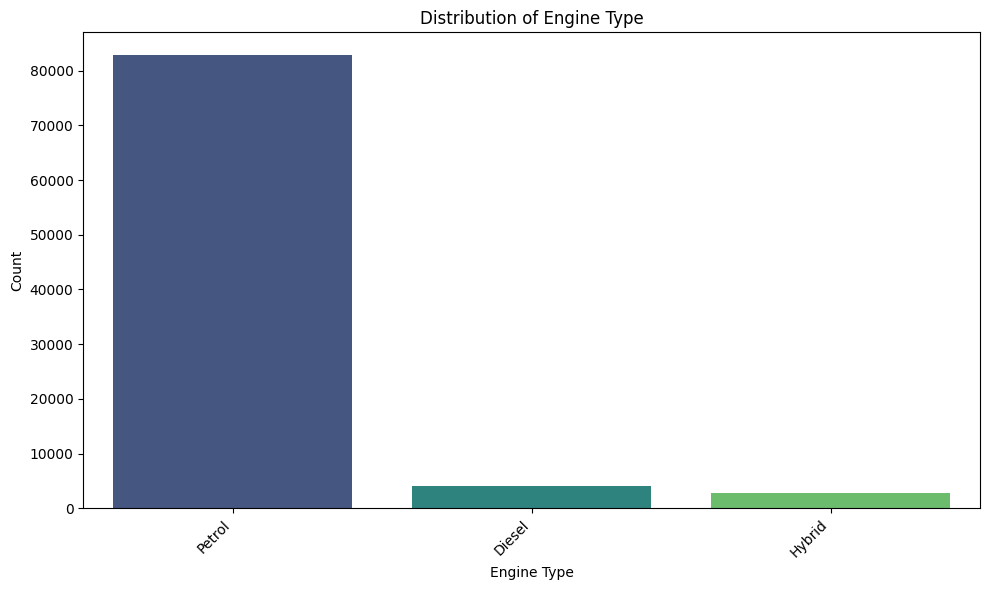

/tmp/ipykernel_55070/2809765206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


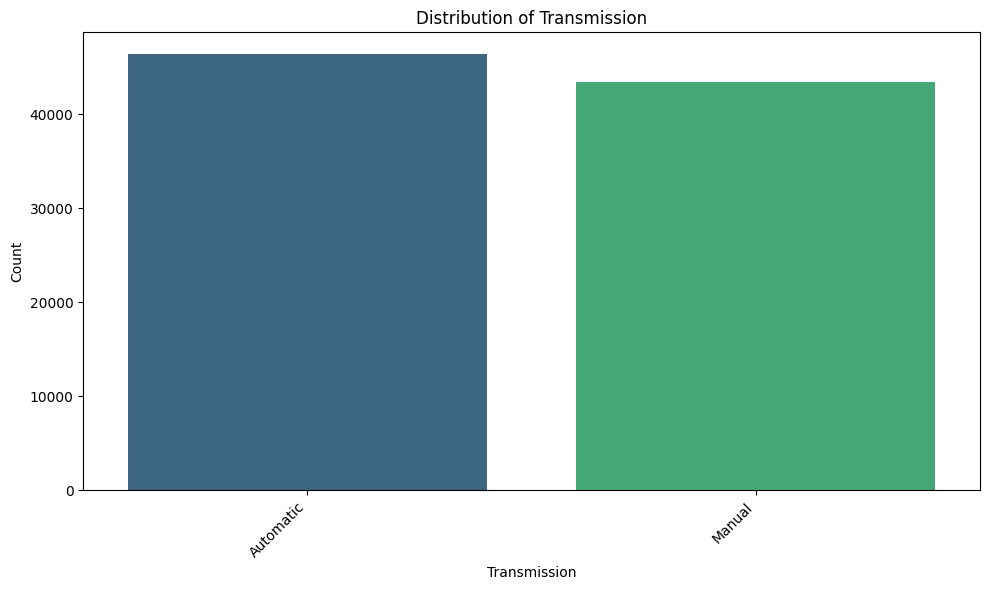

/tmp/ipykernel_55070/2809765206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


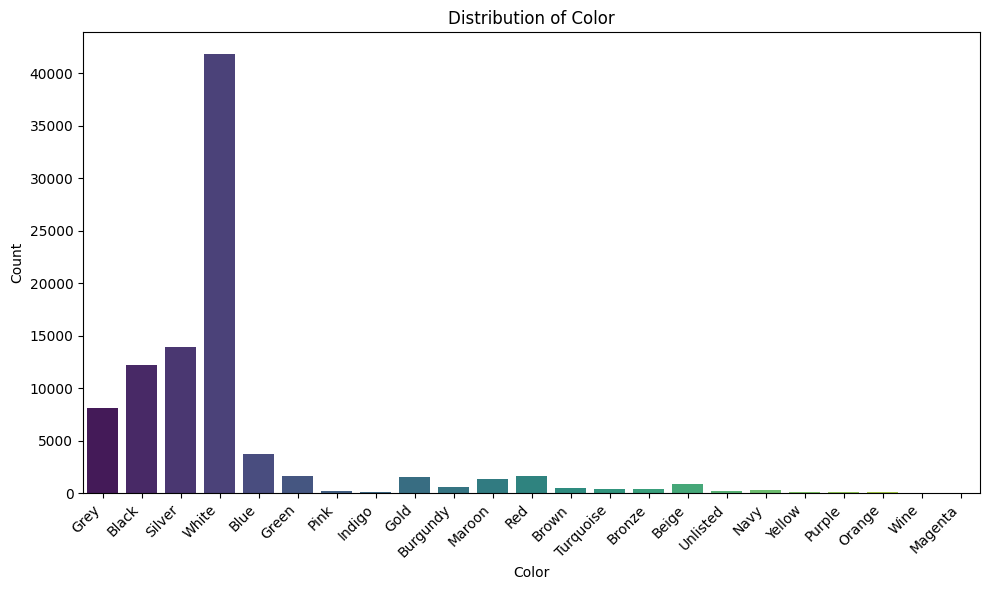

/tmp/ipykernel_55070/2809765206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


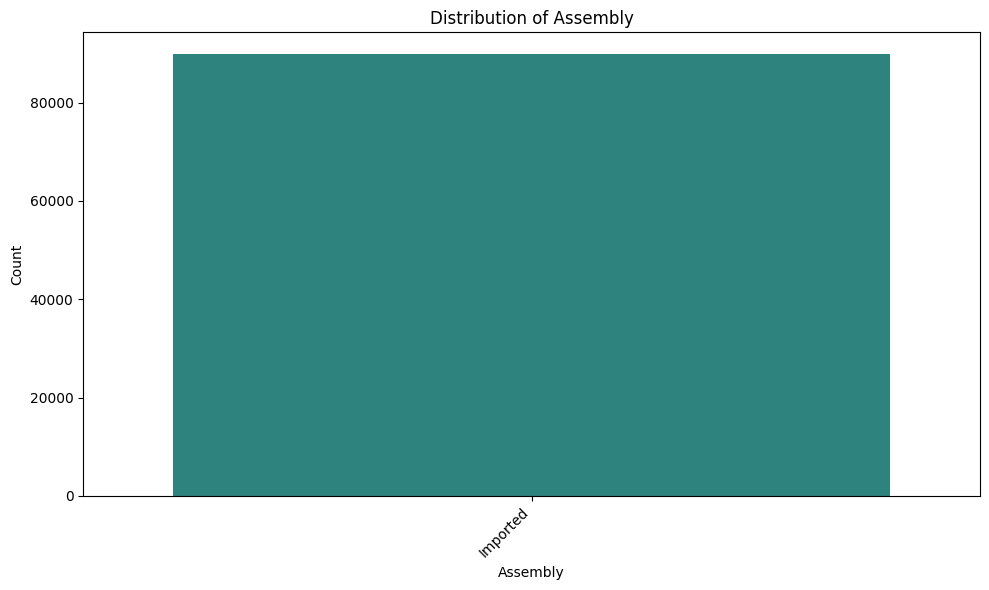

/tmp/ipykernel_55070/2809765206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


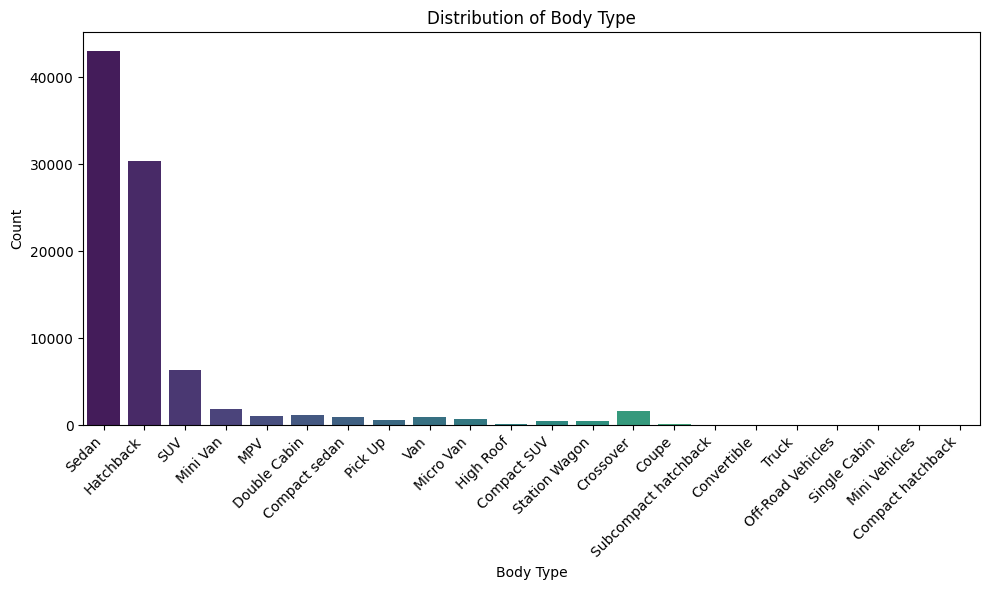

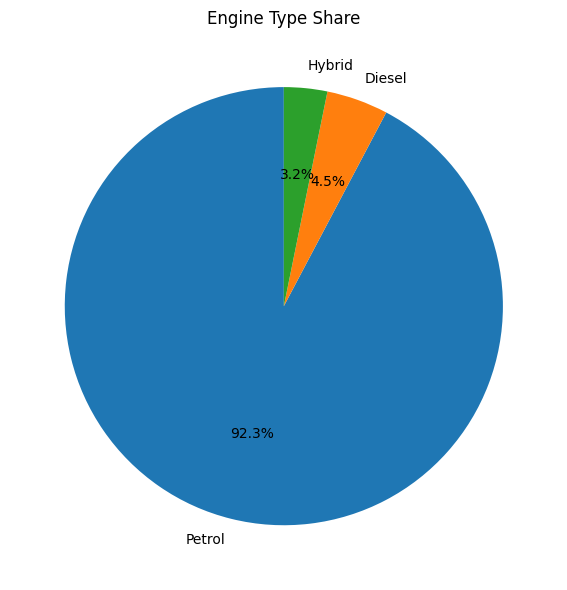

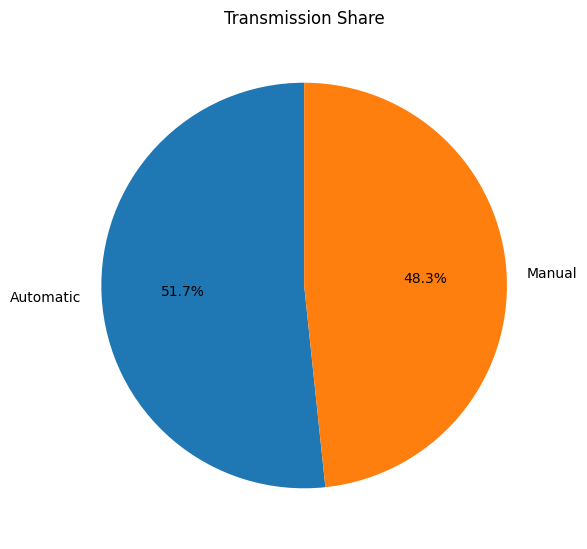

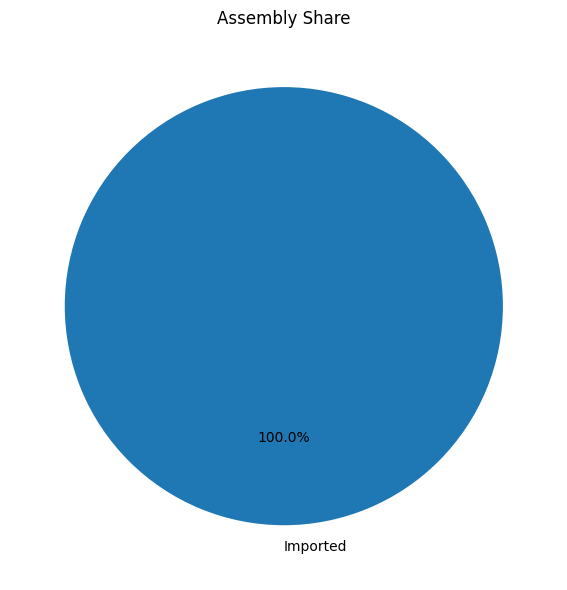

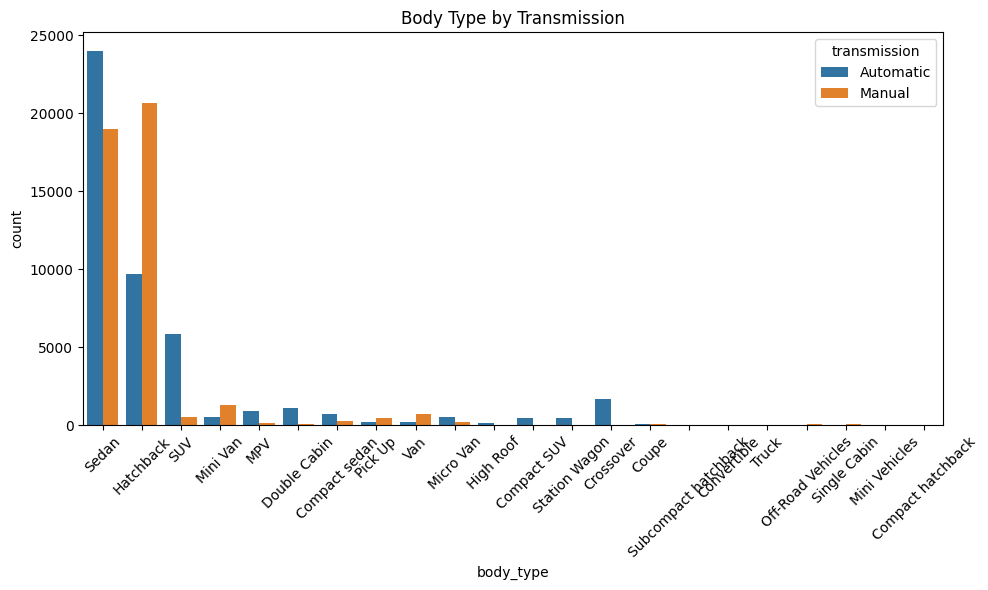

<Figure size 1000x600 with 0 Axes>

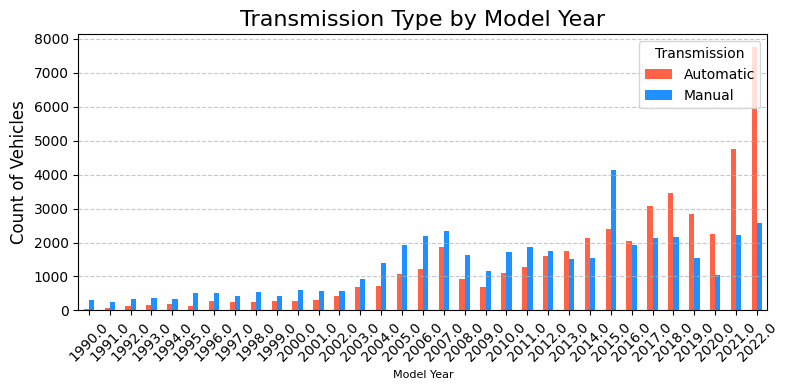

In [ ]:
# Base categorical columns
categorical_cols = [
    'engine_type',
    'transmission',
    'color',
    'assembly',
    'body_type'
]

# Simple countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Count')
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Pie charts for columns with low unique values
for col in ['engine_type', 'transmission', 'assembly']:
    plt.figure(figsize=(6, 6))
    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'{col.replace("_", " ").title()} Share')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# Countplot with hue for interactions
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='body_type', hue='transmission')
plt.xticks(rotation=45)
plt.title('Body Type by Transmission')
plt.tight_layout()
plt.show()


# Transmission by model year grouped bar chart
transmission_counts = (
    df.groupby(['model_year', 'transmission'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(10, 6))
transmission_counts.plot(
    kind='bar',
    figsize=(8, 4),
    rot=45,
    color={
        'Automatic': '#FF6347',
        'Manual': '#1E90FF'
    }
)

plt.title('Transmission Type by Model Year', fontsize=16)
plt.xlabel('Model Year', fontsize=8)
plt.ylabel('Count of Vehicles', fontsize=12)
plt.legend(title='Transmission', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

## **Part (A) - (II)**

Descriptive Statistics for Numerical Columns:

Column: Model Year
  Mean: 2012.91
  Median: 2015.00
  Standard Deviation: 7.57

Column: Price
  Mean: 3002775.27
  Median: 2150000.00
  Standard Deviation: 3895197.94

Column: Mileage
  Mean: 84384.69
  Median: 74000.00
  Standard Deviation: 90474.85

Column: Engine Capacity
  Mean: 1406.18
  Median: 1300.00
  Standard Deviation: 737.01


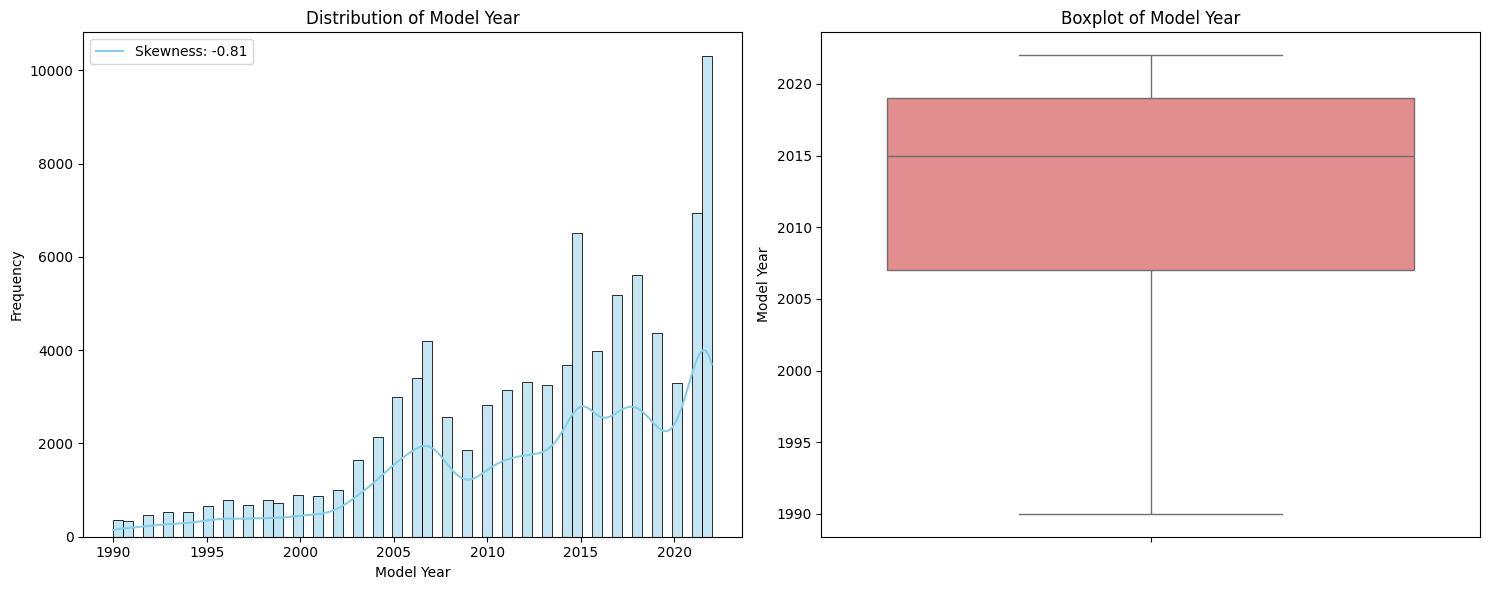

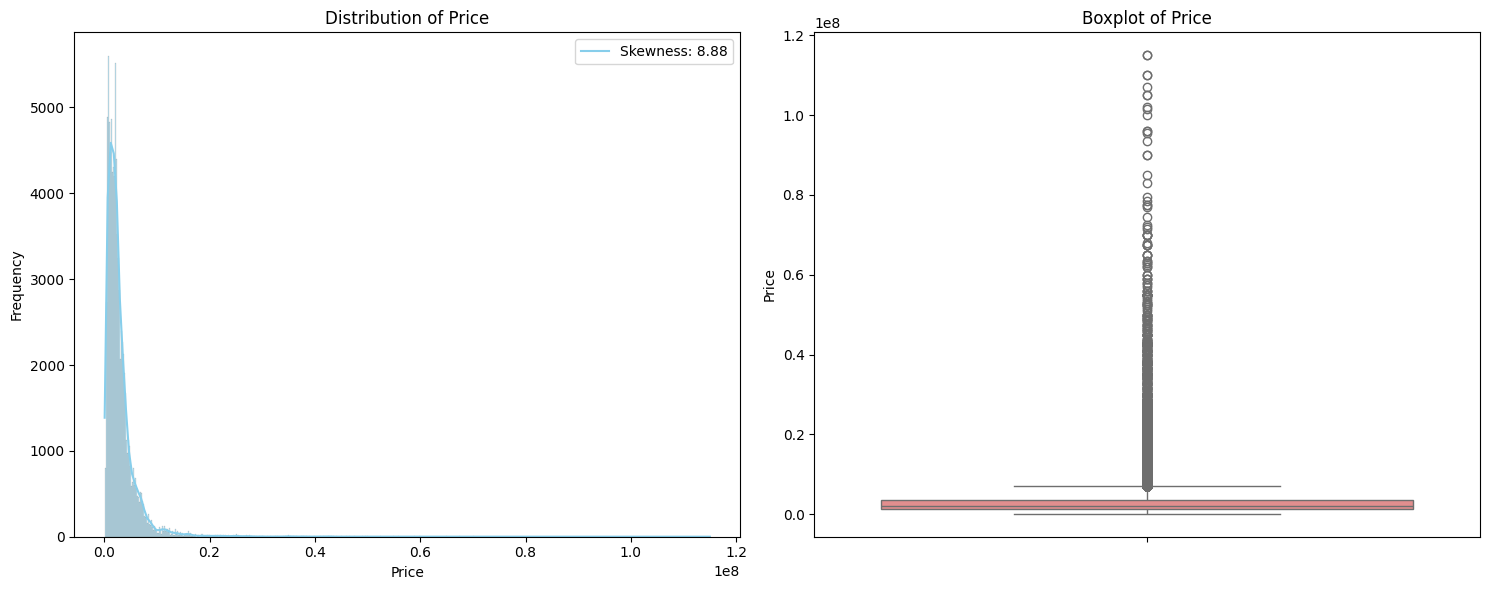

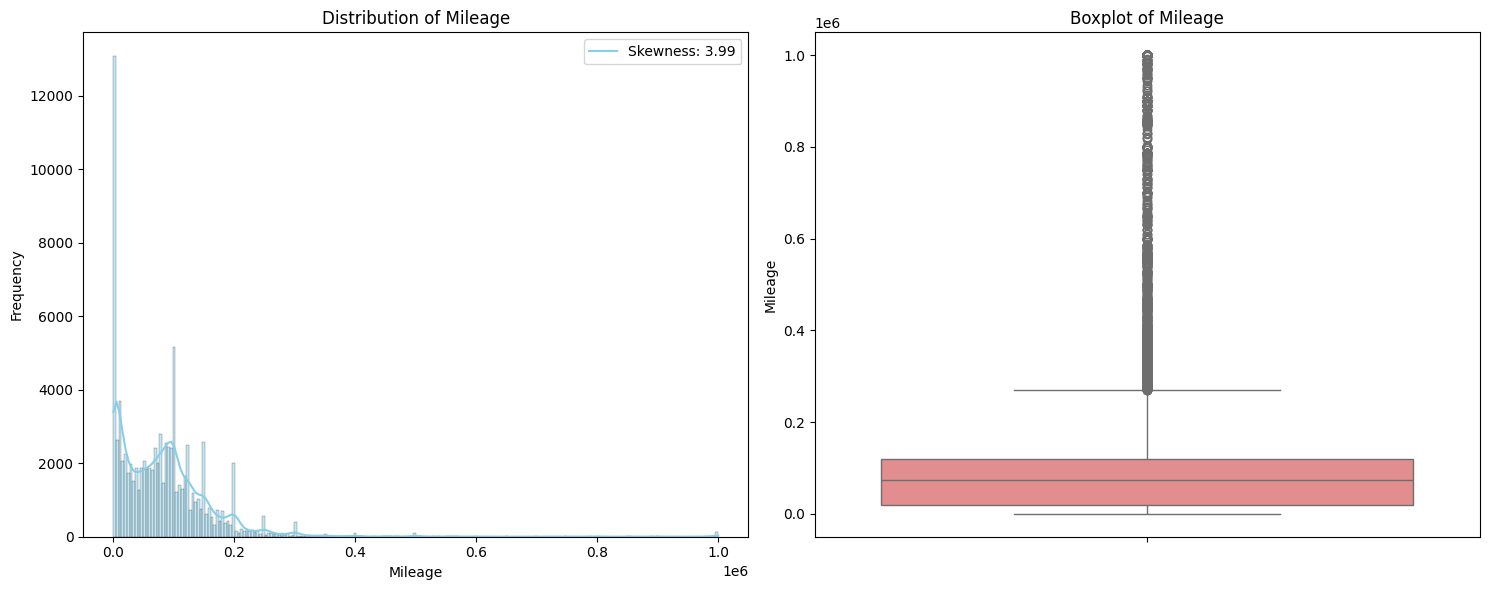

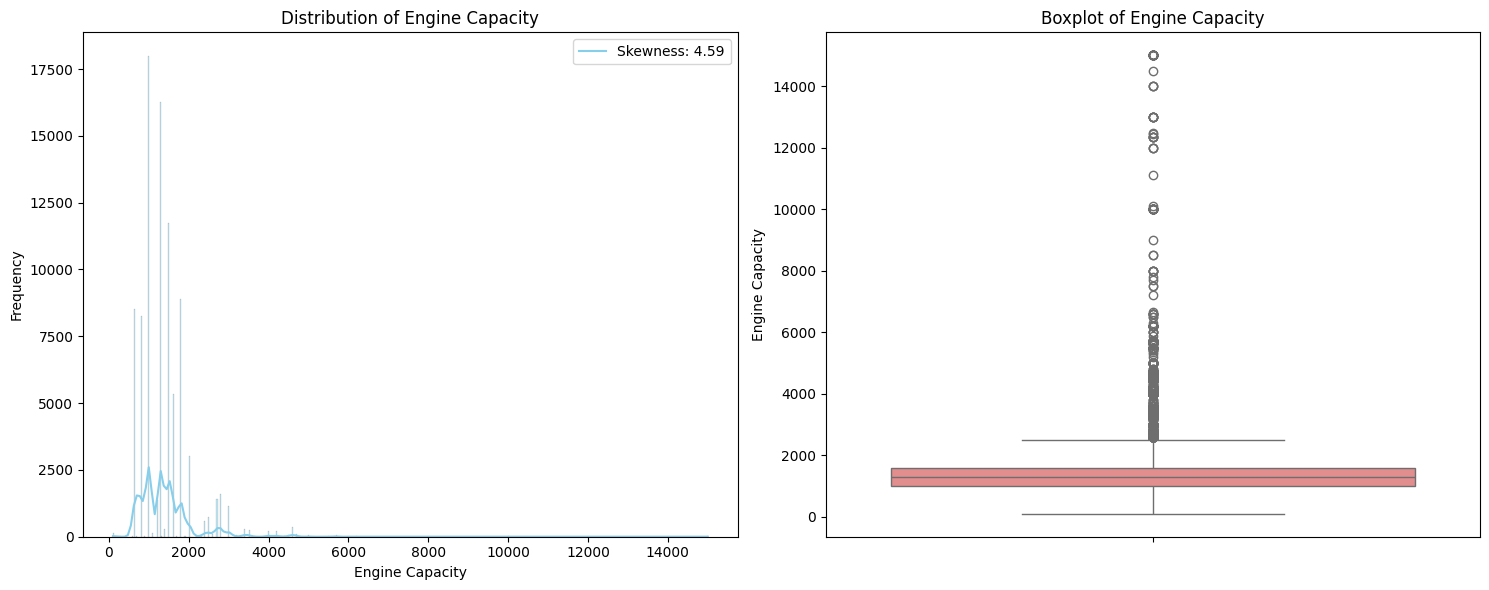

In [ ]:
numerical_cols = ['model_year', 'price', 'mileage', 'engine_capacity']

print("Descriptive Statistics for Numerical Columns:")
for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    print(f"\nColumn: {col.replace('_', ' ').title()}")
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Median: {median_val:.2f}")
    print(f"  Standard Deviation: {std_val:.2f}")
    
    
    
    numerical_cols = ['model_year', 'price', 'mileage', 'engine_capacity']

for col in numerical_cols:
    plt.figure(figsize=(15, 6))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.legend([f'Skewness: {df[col].skew():.2f}']) 

    # Boxplot
    plt.subplot(1, 2, 2) 
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())

    plt.tight_layout()
    plt.show()
    

## **Part (A) - (III)**

###  **Model Year**

* **Skewness:** The distribution is **moderately left-skewed (negative skew)**, with a skewness value of **-0.85**. This is confirmed by the histogram, which shows a tail extending to the left (older cars), and by the statistics, where the **Mean (2012.91) is less than the Median (2015.00)**.
* **Outliers:** The boxplot identifies several **outliers on the low end**. These represent cars from the early 1990s or older, which are statistically rare compared to the main cluster of 2005-2022 models.
* **Transformation Need:** **Likely not needed.** 'Year' is often treated as an ordinal feature or used to create a new feature like 'Car Age'. The moderate skew is generally manageable, and transformations are less common for date-based variables.




###  **Price**

* **Skewness:** The distribution is **extremely right-skewed (positive skew)**, with a very high skewness value of **4.08**. The histogram shows a massive concentration of data at lower prices and a very long tail of expensive cars. This is strongly supported by the **Mean (3,002,775) being significantly higher than the Median (2,150,000)**.
* **Outliers:** The boxplot clearly shows **numerous high-value outliers**. The interquartile range (the box) is compressed at the bottom, indicating that most cars are in a tight price range, while a few are exceptionally expensive.
* **Transformation Need:** **Yes, a transformation is highly recommended.** The extreme skew will violate the assumptions of many linear models. A **log transformation** (e.g., `log(Price)`) is the standard approach to normalize this distribution and reduce the impact of outliers.





### **Mileage**

* **Skewness:** The distribution is **highly right-skewed (positive skew)**, with a skewness value of **1.89**. The histogram shows a peak at lower mileage and a tail extending to the right. The **Mean (84,384) is notably higher than the Median (74,000)**, confirming this skew.
* **Outliers:** The boxplot indicates a large number of **outliers on the high end**, representing cars with exceptionally high mileage compared to the bulk of the data.
* **Transformation Need:** **Yes, a transformation is recommended.** The skew is significant and will affect model performance. A **log transformation** or a **square root transformation** would be appropriate to make the distribution more symmetric.





### **Engine Capacity**

* **Skewness:** The distribution is **extremely right-skewed (positive skew)**, with a skewness value of **4.10**. Like 'Price', the histogram is heavily concentrated at the low end (engines < 2000cc) with a long tail of large-capacity engines. The **Mean (1406.18) is higher than the Median (1300.00)**.
* **Outliers:** The boxplot shows a classic case of **many high-end outliers**. The main body of data is compressed into a thin box at the bottom, with a long stream of dots representing large engines.
* **Transformation Need:** **Yes, a transformation is essential.** This extreme skew is problematic for modeling. A **log transformation** is the most suitable choice to normalize this feature.





### **Summary of Recommendations**

| Column | Skewness Type | Skewness Value | Outliers | Transformation Recommended? |
| :--- | :--- | :--- | :--- | :--- |
| **Model Year** | Left-Skewed | -0.85 | Low-end (old cars) | No, likely not needed. |
| **Price** | Highly Right-Skewed | 4.08 | High-end (expensive) | **Yes (Log Transform)** |
| **Mileage** | Right-Skewed | 1.89 | High-end (high-mileage) | **Yes (Log or Sqrt Transform)** |
| **Engine Capacity**| Highly Right-Skewed | 4.10 | High-end (large engines) | **Yes (Log Transform)** |

## **Part B**

In [ ]:
price = df['price'].dropna()
hypothesized_mean = 1500000  # Rs. 15 lakhs

# Sample statistics
n = len(price)
sample_mean = price.mean()
sample_std = price.std(ddof=1)
sample_se = sample_std / np.sqrt(n)

# Perform one-sample t-test
t_stat, p_val = stats.ttest_1samp(price, popmean=hypothesized_mean)

# 95% Confidence Interval
alpha = 0.05
df_t = n - 1
t_critical = stats.t.ppf(1 - alpha/2, df=df_t)
ci_lower = sample_mean - t_critical * sample_se
ci_upper = sample_mean + t_critical * sample_se

print("="*70)
print("PART B - ONE-SAMPLE T-TEST: VEHICLE PRICE")
print("="*70)
print(f"\nHypotheses:")
print(f"H₀: μ = {hypothesized_mean:,.0f}")
print(f"H₁: μ ≠ {hypothesized_mean:,.0f}")
print(f"\nSample Statistics:")
print(f"n = {n}, x̄ = Rs. {sample_mean:,.2f}, s = Rs. {sample_std:,.2f}")
print(f"\nTest Results:")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_val:.6f}")
print(f"Critical value (α=0.05): ±{t_critical:.4f}")
print(f"\n95% Confidence Interval: ({ci_lower:,.2f}, {ci_upper:,.2f})")
print(f"\nDecision at α=0.05:")
if p_val < alpha:
    print(f"REJECT H₀ (p={p_val:.6f} < 0.05)")
    print(f"Conclusion: Mean price significantly differs from Rs. {hypothesized_mean:,.0f}")
else:
    print(f"✗ FAIL TO REJECT H₀ (p={p_val:.6f} ≥ 0.05)")

PART B - ONE-SAMPLE T-TEST: VEHICLE PRICE

Hypotheses:
H₀: μ = 1,500,000
H₁: μ ≠ 1,500,000

Sample Statistics:
n = 89820, x̄ = Rs. 3,002,775.27, s = Rs. 3,895,197.94

Test Results:
t-statistic = 115.6248, p-value = 0.000000
Critical value (α=0.05): ±1.9600

95% Confidence Interval: (2,977,301.28, 3,028,249.26)

Decision at α=0.05:
 REJECT H₀ (p=0.000000 < 0.05)
Conclusion: Mean price significantly differs from Rs. 1,500,000


## **Part C**

In [ ]:
# Two-sample t-test: Petrol vs Diesel prices
g1 = df[df['engine_type'] == 'Petrol']['price'].dropna()
g2 = df[df['engine_type'] == 'Diesel']['price'].dropna()

g1 = pd.to_numeric(g1, errors='coerce').dropna()
g2 = pd.to_numeric(g2, errors='coerce').dropna()

# Test for equal variances
lev_stat, lev_p = stats.levene(g1, g2)

# Welch's t-test (more robust)
t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)

# Welch-Satterthwaite degrees of freedom
s1, s2 = g1.var(ddof=1), g2.var(ddof=1)
n1, n2 = len(g1), len(g2)
df_welch = ((s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1)))
t_crit = stats.t.ppf(1 - 0.05/2, df=df_welch)

print("\n" + "="*70)
print("PART C - TWO-SAMPLE T-TEST: PETROL vs DIESEL")
print("="*70)
print(f"\nHypotheses:")
print(f"H₀: μ_Petrol = μ_Diesel")
print(f"H₁: μ_Petrol ≠ μ_Diesel")
print(f"\nDescriptive Statistics:")
print(f"Petrol: n={n1}, mean={g1.mean():,.2f}, std={g1.std(ddof=1):,.2f}")
print(f"Diesel: n={n2}, mean={g2.mean():,.2f}, std={g2.std(ddof=1):,.2f}")
print(f"\nLevene's Test: stat={lev_stat:.4f}, p={lev_p:.4f}")
print(f"Variances are {'equal' if lev_p >= 0.05 else 'unequal'} → Using Welch's t-test")
print(f"\nTest Results:")
print(f"t-statistic = {t_stat:.4f}, df = {df_welch:.2f}, p-value = {p_val:.4f}")
print(f"\n(i) Critical Value Method:")
print(f"    Critical value = ±{t_crit:.4f}")
print(f"    |t| = {abs(t_stat):.4f} {'>' if abs(t_stat) > t_crit else '≤'} {t_crit:.4f}")
if abs(t_stat) > t_crit:
    print(f"  REJECT H₀")
else:
    print(f"  FAIL TO REJECT H₀")
print(f"\n(ii) P-value Method:")
print(f"    p-value = {p_val:.4f} {'<' if p_val < 0.05 else '≥'} 0.05")
if p_val < 0.05:
    print(f"  REJECT H₀")
else:
    print(f"  FAIL TO REJECT H₀")
print(f"\nConclusion: {'Significant' if p_val < 0.05 else 'No significant'} difference between Petrol and Diesel prices")



PART C - TWO-SAMPLE T-TEST: PETROL vs DIESEL

Hypotheses:
H₀: μ_Petrol = μ_Diesel
H₁: μ_Petrol ≠ μ_Diesel

Descriptive Statistics:
Petrol: n=82868, mean=2,783,667.01, std=3,650,757.93
Diesel: n=4085, mean=5,912,996.08, std=5,127,443.89

Levene's Test: stat=1826.8368, p=0.0000
Variances are unequal → Using Welch's t-test

Test Results:
t-statistic = -38.5289, df = 4290.54, p-value = 0.0000

(i) Critical Value Method:
    Critical value = ±1.9605
    |t| = 38.5289 > 1.9605
  REJECT H₀

(ii) P-value Method:
    p-value = 0.0000 < 0.05
  REJECT H₀

Conclusion: Significant difference between Petrol and Diesel prices


## **Part D**

In [ ]:
df['model_year_clean'] = pd.to_numeric(df['model_year'], errors='coerce')
bins = [-np.inf, 2010, 2015, np.inf]
labels = ['≤2010', '2011-2015', '≥2016']
df['year_bin'] = pd.cut(df['model_year_clean'], bins=bins, labels=labels)

# Extract groups
groups = []
group_labels = []
for lab in labels:
    g = df[df['year_bin'] == lab]['price'].dropna()
    g = pd.to_numeric(g, errors='coerce').dropna()
    if len(g) >= 3:
        groups.append(g)
        group_labels.append(lab)

print(f"\nHypotheses:")
print(f"H₀: μ₁ = μ₂ = μ₃ (all groups have equal means)")
print(f"H₁: At least one group mean differs")

# Descriptive statistics
print(f"\nDescriptive Statistics:")
for lab, g in zip(group_labels, groups):
    print(f"{lab}: n={len(g)}, mean={g.mean():,.2f}, std={g.std(ddof=1):,.2f}")

# Assumption Testing
print(f"\n--- Assumption Testing ---")

# Normality test
print(f"\nNormality (Shapiro-Wilk):")
normality_results = []
for lab, g in zip(group_labels, groups):
    if 3 <= len(g) <= 5000:
        stat, p = stats.shapiro(g)
        is_normal = p >= 0.05
        normality_results.append(is_normal)
        print(f"  {lab}: W={stat:.4f}, p={p:.4f} → {'Normal' if is_normal else 'Not Normal'}")

all_normal = all(normality_results)

# Homogeneity of variances
lev_stat, lev_p = stats.levene(*groups)
equal_var = lev_p >= 0.05
print(f"\nHomogeneity of Variances (Levene): stat={lev_stat:.4f}, p={lev_p:.4f}")
print(f"  → Variances are {'equal' if equal_var else 'unequal'}")

assumptions_met = all_normal and equal_var
print(f"\nAssumptions: {'Met (use ANOVA)' if assumptions_met else '✗ Violated (use Kruskal-Wallis)'}")

# Perform tests
print(f"\n--- Statistical Tests ---")

# ANOVA
f_stat, anova_p = stats.f_oneway(*groups)
df_between = len(groups) - 1
df_within = sum(len(g) for g in groups) - len(groups)
f_crit_05 = stats.f.ppf(0.95, df_between, df_within)
f_crit_01 = stats.f.ppf(0.99, df_between, df_within)

print(f"\nANOVA: F={f_stat:.4f}, p={anova_p:.6f}")
print(f"  Critical values: F_0.05={f_crit_05:.4f}, F_0.01={f_crit_01:.4f}")

# Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*groups)
df_kw = len(groups) - 1
chi2_crit_05 = stats.chi2.ppf(0.95, df_kw)
chi2_crit_01 = stats.chi2.ppf(0.99, df_kw)

print(f"\nKruskal-Wallis: H={kw_stat:.4f}, p={kw_p:.6f}")
print(f"  Critical values: χ²_0.05={chi2_crit_05:.4f}, χ²_0.01={chi2_crit_01:.4f}")

# Results at different significance levels
print(f"\n--- Hypothesis Test Results ---")

recommended_test = "ANOVA" if assumptions_met else "Kruskal-Wallis"
recommended_p_05 = anova_p if assumptions_met else kw_p
recommended_p_01 = anova_p if assumptions_met else kw_p

print(f"\nRecommended Test: {recommended_test}")
print(f"\nAt α = 0.05:")
if recommended_p_05 < 0.05:
    print(f"REJECT H₀ (p={recommended_p_05:.6f} < 0.05)")
    print(f"  Conclusion: Significant difference in prices across model year groups")
else:
    print(f"FAIL TO REJECT H₀ (p={recommended_p_05:.6f} ≥ 0.05)")
    print(f"  Conclusion: No significant difference in prices")

print(f"\nAt α = 0.01:")
if recommended_p_01 < 0.01:
    print(f"REJECT H₀ (p={recommended_p_01:.6f} < 0.01)")
    print(f"  Conclusion: Significant difference in prices across model year groups")
else:
    print(f"FAIL TO REJECT H₀ (p={recommended_p_01:.6f} ≥ 0.01)")
    print(f"  Conclusion: No significant difference in prices")


Hypotheses:
H₀: μ₁ = μ₂ = μ₃ (all groups have equal means)
H₁: At least one group mean differs

Descriptive Statistics:
≤2010: n=30191, mean=1,573,661.36, std=1,782,599.28
2011-2015: n=19926, mean=2,347,384.92, std=2,886,691.18
≥2016: n=39703, mean=4,418,428.66, std=4,894,300.33

--- Assumption Testing ---

Normality (Shapiro-Wilk):

Homogeneity of Variances (Levene): stat=1314.7931, p=0.0000
  → Variances are unequal

Assumptions: ✗ Violated (use Kruskal-Wallis)

--- Statistical Tests ---

ANOVA: F=5545.5584, p=0.000000
  Critical values: F_0.05=2.9958, F_0.01=4.6054

Kruskal-Wallis: H=34726.1280, p=0.000000
  Critical values: χ²_0.05=5.9915, χ²_0.01=9.2103

--- Hypothesis Test Results ---

Recommended Test: Kruskal-Wallis

At α = 0.05:
REJECT H₀ (p=0.000000 < 0.05)
  Conclusion: Significant difference in prices across model year groups

At α = 0.01:
REJECT H₀ (p=0.000000 < 0.01)
  Conclusion: Significant difference in prices across model year groups


## **Part E**

In [ ]:
decision_05 = recommended_p_05 < 0.05
decision_01 = recommended_p_01 < 0.01
decision_changed = decision_05 != decision_01

print(f"\nComparison of Results:")
print(f"  α = 0.05: {'Reject H₀' if decision_05 else 'Fail to Reject H₀'}")
print(f"  α = 0.01: {'Reject H₀' if decision_01 else 'Fail to Reject H₀'}")
print(f"  p-value: {recommended_p_05:.6f}")

if decision_changed:
    print(f"\n✗ Decision CHANGED when significance level changed")
    print(f"  → p-value falls between 0.01 and 0.05 (moderate evidence)")
    print(f"  → More conservative α (0.01) requires stronger evidence")
else:
    print(f"\nDecision CONSISTENT across significance levels")
    if decision_05:
        print(f"  → Strong evidence against H₀ (p < 0.01)")
    else:
        print(f"  → Weak evidence against H₀ (p > 0.05)")


Comparison of Results:
  α = 0.05: Reject H₀
  α = 0.01: Reject H₀
  p-value: 0.000000

Decision CONSISTENT across significance levels
  → Strong evidence against H₀ (p < 0.01)


## **Part F**

Sample size: n = 89820

Correlation Matrix:
                 model_year   price  mileage  engine_capacity
model_year           1.0000  0.3123  -0.4320          -0.0632
price                0.3123  1.0000  -0.1906           0.5097
mileage             -0.4320 -0.1906   1.0000           0.0351
engine_capacity     -0.0632  0.5097   0.0351           1.0000

Pair                                     r        p-value      95% CI                    Sig  
------------------------------------------------------------------------------------------
model_year × price                          0.3123   0.000000     [0.3064, 0.3182] ***
model_year × mileage                        -0.4320  0.000000     [-0.4373, -0.4267] ***
model_year × engine_capacity                -0.0632  0.000000     [-0.0697, -0.0567] ***
price × mileage                        -0.1906  0.000000     [-0.1969, -0.1843] ***
price × engine_capacity                0.5097   0.000000     [0.5048, 0.5145] ***
mileage × engine_capacity   

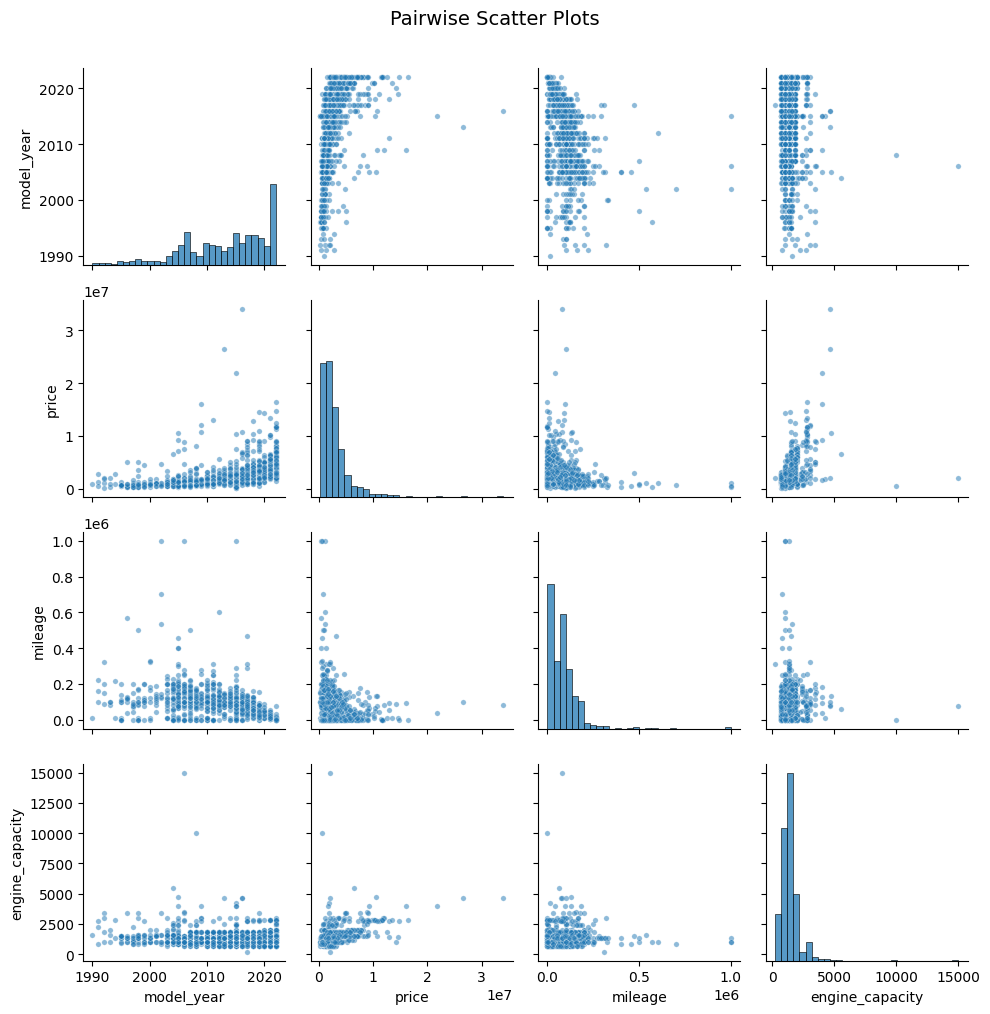

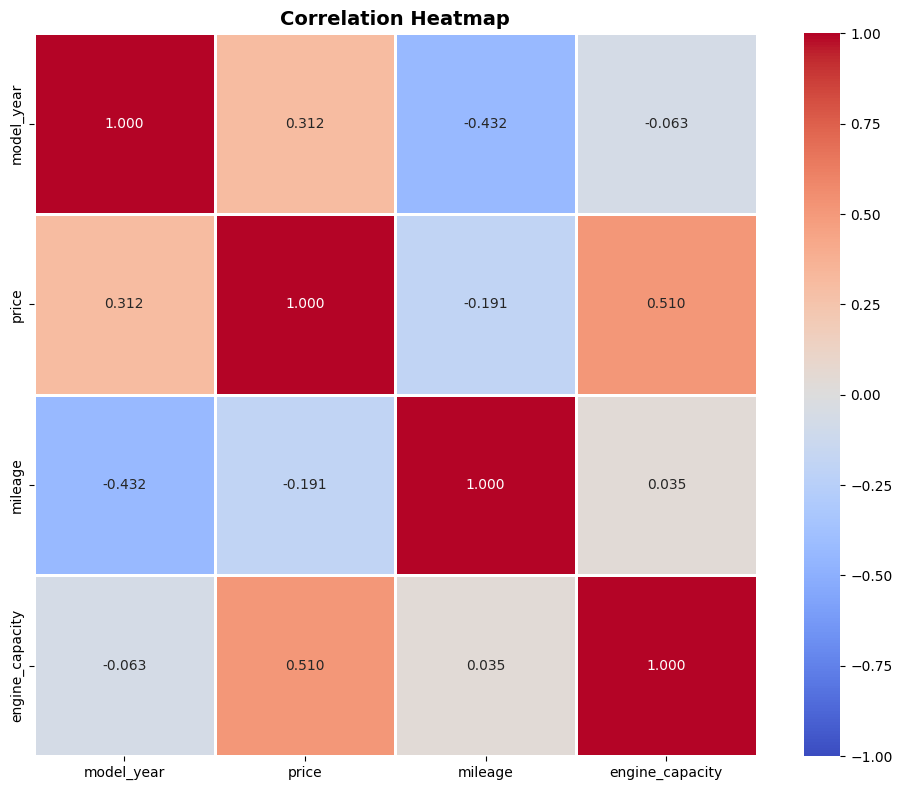

In [ ]:
numerical_cols = ['model_year', 'price', 'mileage', 'engine_capacity']
numeric_data = df[numerical_cols].apply(pd.to_numeric, errors='coerce').dropna()

print(f"Sample size: n = {len(numeric_data)}")

# Compute correlation matrix
corr_matrix = numeric_data.corr(method='pearson')

print("\nCorrelation Matrix:")
print(corr_matrix.round(4))

# Detailed statistics with p-values and CIs
print(f"\n{'Pair':<40} {'r':<8} {'p-value':<12} {'95% CI':<25} {'Sig':<5}")
print("-"*90)

for var1, var2 in combinations(numerical_cols, 2):
    paired = numeric_data[[var1, var2]].dropna()
    n = len(paired)
    
    if n >= 3:
        r, p = stats.pearsonr(paired[var1], paired[var2])
        
        # Fisher's z-transformation for CI
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_crit = stats.norm.ppf(0.975)
        ci_low = np.tanh(z - z_crit * se)
        ci_high = np.tanh(z + z_crit * se)
        
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        
        print(f"{var1} × {var2:<30} {r:<8.4f} {p:<12.6f} [{ci_low:.4f}, {ci_high:.4f}] {sig}")

print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

# Interpretation
print("\nInterpretation:")
corr_results = []
for var1, var2 in combinations(numerical_cols, 2):
    paired = numeric_data[[var1, var2]].dropna()
    if len(paired) >= 3:
        r, p = stats.pearsonr(paired[var1], paired[var2])
        corr_results.append((var1, var2, r, p))

# Sort by absolute correlation
corr_results.sort(key=lambda x: abs(x[2]), reverse=True)

for var1, var2, r, p in corr_results[:3]:
    strength = 'Strong' if abs(r) >= 0.7 else 'Moderate' if abs(r) >= 0.4 else 'Weak'
    direction = 'positive' if r > 0 else 'negative'
    sig_text = 'significant' if p < 0.05 else 'not significant'
    print(f"  {var1} × {var2}: {strength} {direction} correlation (r={r:.4f}, {sig_text})")

# Visualizations
# 1. Pairplot
sample_data = numeric_data.sample(n=min(1000, len(numeric_data)), random_state=42)
pairplot = sns.pairplot(sample_data, diag_kind='hist', 
                        plot_kws={'alpha': 0.5, 's': 15},
                        diag_kws={'bins': 30, 'edgecolor': 'black'})
pairplot.fig.suptitle('Pairwise Scatter Plots', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# 2. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Part G**


Observed difference: Rs. -3,129,329.07
Performing bootstrap with 1000 iterations...

Bootstrap Results:
  95% CI: [-3,281,093.30, -2,984,267.26]
  p-value: 0.000000
  CI includes 0: No

Bootstrap Decision at α=0.05:
REJECT H₀

--- Comparison with Original T-test ---
Method               Decision             p-value        
-------------------------------------------------------
Welch's t-test       Reject H₀            0.000000
Bootstrap            Reject H₀            0.000000

Methods agree: 

Analysis:
  Petrol skewness: 9.75
  Diesel skewness: 3.06
  → Data is highly skewed (from Part A analysis)
  → Bootstrap is more appropriate (no normality assumption)
  → Results are robust to method choice


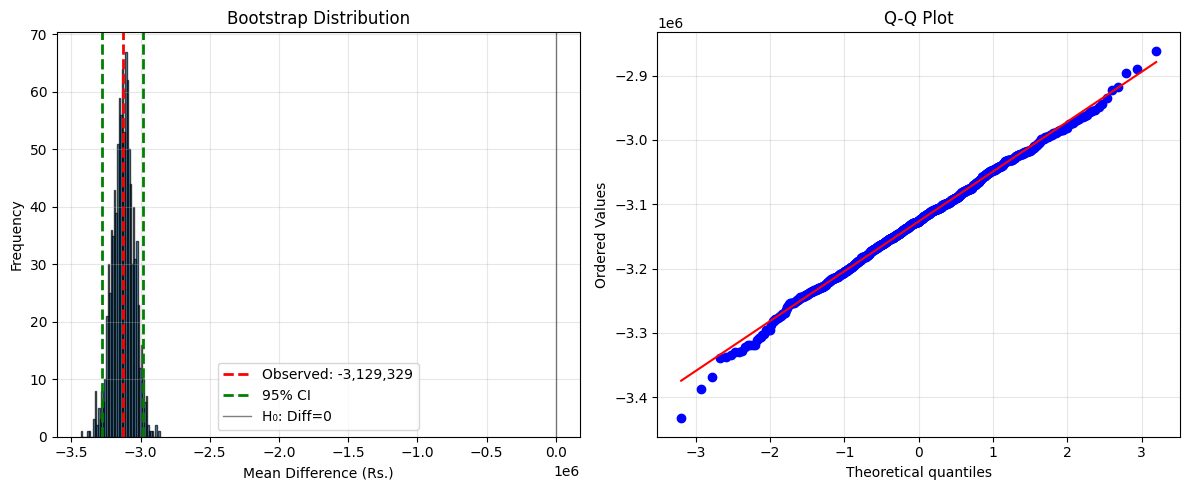

In [ ]:
# Extract groups
g1 = df[df['engine_type'] == 'Petrol']['price'].dropna()
g2 = df[df['engine_type'] == 'Diesel']['price'].dropna()
g1 = pd.to_numeric(g1, errors='coerce').dropna()
g2 = pd.to_numeric(g2, errors='coerce').dropna()

observed_diff = g1.mean() - g2.mean()

print(f"\nObserved difference: Rs. {observed_diff:,.2f}")
print(f"Performing bootstrap with 1000 iterations...")

# Bootstrap resampling
np.random.seed(42)
B = 1000
boot_diffs = np.empty(B)

for i in range(B):
    sample1 = g1.sample(n=len(g1), replace=True)
    sample2 = g2.sample(n=len(g2), replace=True)
    boot_diffs[i] = sample1.mean() - sample2.mean()

# Bootstrap CI (percentile method)
ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])

# Bootstrap p-value
p_value_boot = 2 * min(np.mean(boot_diffs >= 0), np.mean(boot_diffs <= 0))

print(f"\nBootstrap Results:")
print(f"  95% CI: [{ci_lower:,.2f}, {ci_upper:,.2f}]")
print(f"  p-value: {p_value_boot:.6f}")
print(f"  CI includes 0: {'Yes' if ci_lower <= 0 <= ci_upper else 'No'}")

decision_boot = not (ci_lower <= 0 <= ci_upper) or p_value_boot < 0.05

print(f"\nBootstrap Decision at α=0.05:")
if decision_boot:
    print(f"REJECT H₀")
else:
    print(f"FAIL TO REJECT H₀")

# Comparison with original t-test
t_stat, p_val_ttest = stats.ttest_ind(g1, g2, equal_var=False)
decision_ttest = p_val_ttest < 0.05

print(f"\n--- Comparison with Original T-test ---")
print(f"{'Method':<20} {'Decision':<20} {'p-value':<15}")
print("-"*55)
print(f"{'Welch\'s t-test':<20} {'Reject H₀' if decision_ttest else 'Fail to Reject':<20} {p_val_ttest:.6f}")
print(f"{'Bootstrap':<20} {'Reject H₀' if decision_boot else 'Fail to Reject':<20} {p_value_boot:.6f}")

agreement = decision_ttest == decision_boot
print(f"\nMethods {'agree' if agreement else 'DISAGREE'}: {'' if agreement else '✗'}")

print(f"\nAnalysis:")
skew1, skew2 = g1.skew(), g2.skew()
print(f"  Petrol skewness: {skew1:.2f}")
print(f"  Diesel skewness: {skew2:.2f}")

if abs(skew1) > 1 or abs(skew2) > 1:
    print(f"  → Data is highly skewed (from Part A analysis)")
    print(f"  → Bootstrap is more appropriate (no normality assumption)")
else:
    print(f"  → Data is approximately normal")
    print(f"  → Both methods are reliable")

if agreement:
    print(f"  → Results are robust to method choice")
else:
    print(f"  → Bootstrap result is more reliable for skewed data")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(boot_diffs, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed: {observed_diff:,.0f}')
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label=f'95% CI')
plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2)
plt.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='H₀: Diff=0')
plt.xlabel('Mean Difference (Rs.)')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
stats.probplot(boot_diffs, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()